In [28]:
import os
import sys
import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve, classification_report
from sklearn.datasets import make_classification
from xgboost import XGBClassifier
from xgboost import plot_importance
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

import lightgbm as lgbm

from utils import user_utils

In [2]:
raw_df = pd.read_csv('../data/creditcard.csv')
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [3]:
def get_outlier(df, columns=None, weight=1.5):
    """
    IQR 기반 이상치 탐지 함수
    df: DataFrame
    columns: 특정 컬럼 리스트 (None이면 전체 수치형 컬럼)
    weight: IQR 배수 (기본 1.5)
    """
    # 사용할 컬럼 선택
    if columns is None:
        columns = df.select_dtypes(include="number").columns
    
    # 사분위수 계산
    Q1 = df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 - Q1
    
    # 이상치 기준
    lower_bound = Q1 - weight * IQR
    upper_bound = Q3 + weight * IQR
    
    # 이상치 마스크
    outlier_mask = pd.DataFrame(False, index=df.index, columns=columns)
    for col in columns:
        outlier_mask[col] = (df[col] < lower_bound[col]) | (df[col] > upper_bound[col])
    
    # 결과 요약
    outlier_bounds = pd.DataFrame({
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "LowerBound": lower_bound,
        "UpperBound": upper_bound,
        "OutlierCount": outlier_mask.sum()
    })
    
    return outlier_bounds


In [4]:
def get_outlier_idx(df, columns=None, weight=1.5):
    """
    IQR 기반 이상치 탐지 함수
    df: DataFrame
    columns: 특정 컬럼 리스트 (None이면 전체 수치형 컬럼)
    weight: IQR 배수 (기본 1.5)
    """
    # 사용할 컬럼 선택
    if columns is None:
        columns = df.select_dtypes(include="number").columns
        
    fraud = df[df['Class']==1][columns]
    
    # 사분위수 계산
    Q1 = np.percentile(fraud.values, 25)
    Q3 = np.percentile(fraud.values, 75)
    IQR = Q3 - Q1
    
    # 이상치 기준
    lower_bound = Q1 - weight * IQR
    upper_bound = Q3 + weight * IQR
    
    outlier_index = fraud[(fraud < lower_bound) | (fraud > upper_bound)].index
    return outlier_index

In [15]:
outlier_index = get_outlier_idx(raw_df, 'V16')

raw_df.iloc[outlier_index,:]['V16']

Series([], Name: V16, dtype: float64)

In [5]:
get_outlier(raw_df)

,Q1,Q3,IQR,LowerBound,UpperBound,OutlierCount
Time,54201.500000,139320.500000,85119.000000,-73477.000000,266999.000000,0
V1,-0.920373,1.315642,2.236015,-4.274396,4.669664,7062
V2,-0.598550,0.803724,1.402274,-2.701961,2.907135,13526
V3,-0.890365,1.027196,1.917560,-3.766705,3.903536,3363
V4,-0.848640,0.743341,1.591981,-3.236612,3.131313,11148
V5,-0.691597,0.611926,1.303524,-2.646882,2.567212,12295
V6,-0.768296,0.398565,1.166861,-2.518586,2.148856,22965
V7,-0.554076,0.570436,1.124512,-2.240844,2.257204,8948
V8,-0.208630,0.327346,0.535976,-1.012593,1.131309,24134
V9,-0.643098,0.597139,1.240237,-2.503452,2.457494,8283


In [ ]:
raw_df.drop(['Time'], axis=1, inplace=True)
X_feature = raw_df.iloc[:,:-1]
y_label = raw_df.iloc[:,-1]

In [9]:
# 학습/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_feature,
    y_label,
    test_size = 0.2,
    stratify = y_label,
    random_state = 42
)

In [29]:
catboost = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,        # 학습률 (수치형 미세 패턴 학습을 위해 약간 낮춤)
    depth=6,
    l2_leaf_reg=3,             # L2 정규화 (수치형 데이터의 노이즈 과적합 방지)
    
    # *** 불균형 데이터 핵심 설정 ***
    # 방법 1: 자동 가중치 (추천)
    auto_class_weights='Balanced', 
    
    # 방법 2: 수동 가중치 계산 (참고용)
    # scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train),
    
    eval_metric='AUC',         # 평가 지표
    early_stopping_rounds=100, # 과적합 방지
    verbose=100,
    random_seed=23
)

gb_clf = GradientBoostingClassifier(
    n_estimators=100,      # 트리 개수
    learning_rate=0.1,     # 학습률
    max_depth=3,           # 개별 트리 깊이
    random_state=42
)

dt_clf = DecisionTreeClassifier(
    criterion="gini",   # 분할 기준 (gini, entropy)
    max_depth=None,     # 트리 최대 깊이 (None이면 제한 없음)
    random_state=42
)

mlp_clf = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=256,
    learning_rate="adaptive",
    max_iter=50,           # increase with early stopping if desired
    random_state=23
)

lr_clf = LogisticRegression(
    max_iter = 1000,
    class_weight = 'balanced',
    random_state = 23
)

In [30]:
# user_utils.get_model_train_eval(catboost,'rawdata_catboost_20251126',X_train,X_test,y_train,y_test)
# user_utils.get_model_train_eval(gb_clf,'rawdata_gb_20251126',X_train,X_test,y_train,y_test)
# user_utils.get_model_train_eval(dt_clf,'rawdata_dt_20251126',X_train,X_test,y_train,y_test)
# user_utils.get_model_train_eval(mlp_clf,'rawdata_mlp_20251126',X_train,X_test,y_train,y_test)
user_utils.get_model_train_eval(lr_clf,'rawdata_lr_20251126',X_train,X_test,y_train,y_test)

✓ 모델 저장 완료: ../models\rawdata_lr_20251126.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9892, 정확도: 0.9683, 정밀도: 0.0486, 재현율: 0.9388, F1: 0.0924
오차행렬:
[[55062  1801]
 [    6    92]]
실행 시간: 1.055069923400879


In [20]:
# amount_n = np.log1p(raw_df['Amount'])
# raw_df.insert(0,'Amount Scaled', amount_n)
raw_df.drop(['Amount'], axis=1, inplace=True)
outlier_index = get_outlier_idx(raw_df, 'V14')
raw_df.drop(outlier_index, axis=0, inplace=True)
raw_df

,Amount Scaled,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,5.014760,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,1.305626,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,5.939276,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,4.824306,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,4.262539,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,0.570980,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0
284803,3.249987,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0
284804,4.232366,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0
284805,2.397895,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0


In [ ]:
# raw_df.to_csv('../data/scaledAmount_data.csv',index=False)

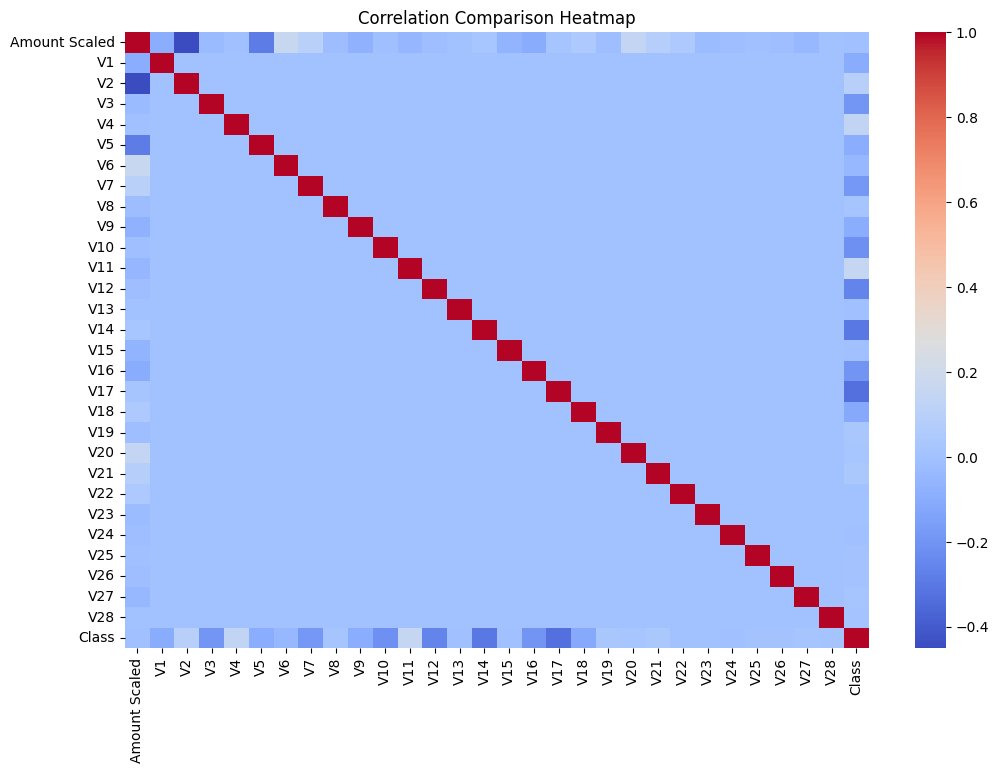

In [17]:
columns = raw_df.select_dtypes(include="number").columns
corr_matrix = raw_df[columns].corr()
    
    # 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Comparison Heatmap")
plt.show()


In [7]:
def cap_outliers(df, columns=None, weight=1.5):
    """
    IQR 기반으로 이상치를 탐지하고 상한/하한 값으로 대체(Capping)하는 함수.
    
    df: DataFrame
    columns: 특정 컬럼 리스트 (None이면 전체 수치형 컬럼)
    weight: IQR 배수 (기본 1.5)
    """
    df_capped = df.copy()
    
    # 처리할 컬럼 선택
    if columns is None:
        columns = df_capped.select_dtypes(include=np.number).columns
    
    for col in columns:
        # 사분위수 및 IQR 계산
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # 이상치 경계 계산
        lower_bound = Q1 - weight * IQR
        upper_bound = Q3 + weight * IQR
        
        # Capping 적용
        df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)
        
    return df_capped

In [21]:
scaled_df = pd.read_csv('../data/scaledAmount_data.csv')


In [22]:
temp_X_feature = scaled_df.iloc[:,:-1]
y_label = scaled_df.iloc[:,-1]

X_feature = cap_outliers(temp_X_feature)

In [23]:
# 학습/검증 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_feature,
    y_label,
    test_size = 0.2,
    stratify = y_label,
    random_state = 42
)

In [ ]:
# catboost = CatBoostClassifier(
#     iterations=1000,
#     learning_rate=0.03,        # 학습률 (수치형 미세 패턴 학습을 위해 약간 낮춤)
#     depth=6,
#     l2_leaf_reg=3,             # L2 정규화 (수치형 데이터의 노이즈 과적합 방지)
    
#     # *** 불균형 데이터 핵심 설정 ***
#     # 방법 1: 자동 가중치 (추천)
#     auto_class_weights='Balanced', 
    
#     # 방법 2: 수동 가중치 계산 (참고용)
#     # scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train),
    
#     eval_metric='AUC',         # 평가 지표
#     early_stopping_rounds=100, # 과적합 방지
#     verbose=100,
#     random_seed=23
# )

In [24]:
# catboost.fit(
#     X_train, y_train,
#     eval_set=(X_test, y_test),
#     use_best_model=True
# )
user_utils.get_model_train_eval(catboost,'capped_data_catboost_20251126',X_train,X_test,y_train,y_test)

0:	total: 32.1ms	remaining: 32s
100:	total: 3.17s	remaining: 28.2s
200:	total: 6.39s	remaining: 25.4s
300:	total: 9.46s	remaining: 22s
400:	total: 12.6s	remaining: 18.8s
500:	total: 15.7s	remaining: 15.6s
600:	total: 18.6s	remaining: 12.4s
700:	total: 21.1s	remaining: 9.02s
800:	total: 23.5s	remaining: 5.84s
900:	total: 26s	remaining: 2.86s
999:	total: 28.4s	remaining: 0us
✓ 모델 저장 완료: ../models\capped_data_catboost_20251126.pkl
  파일 크기: 1.04 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9889, 정확도: 0.9992, 정밀도: 0.7350, 재현율: 0.8776, F1: 0.8000
오차행렬:
[[56832    31]
 [   12    86]]
실행 시간: 28.86259913444519


In [ ]:
### result
# bestTest = 0.9806344246
# bestIteration = 205

### V14 drop
#bestTest = 0.9951118639
#bestIteration = 19

In [ ]:
# y_pred_probs = catboost.predict_proba(X_test)[:, 1]
# y_pred = catboost.predict(X_test)
# # Precision-Recall Curve를 통한 최적 Threshold 탐색
# precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_probs)

# # F1-Score가 최대가 되는 지점 찾기
# f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
# best_idx = np.argmax(f1_scores)
# best_threshold = thresholds[best_idx]

# print(f"\n>>> Best Threshold: {best_threshold:.4f}")

# # 최적 임계값 적용 예측
# y_pred_custom = (y_pred_probs >= best_threshold).astype(int)

# print("\n--- Final Evaluation (Custom Threshold) ---")
# print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_probs):.4f}")
# print(f'recall: {recall_score(y_test, y_pred):.4f}')
# print(f'precision: {precision_score(y_test, y_pred):.4f}')
# print(classification_report(y_test, y_pred_custom))
#>>> Best Threshold: 0.9367

# --- Final Evaluation (Custom Threshold) ---
# ROC-AUC: 0.9806
# recall: 0.8776
# precision: 0.3772

### drop V14
# >>> Best Threshold: 0.8339

# --- Final Evaluation (Custom Threshold) ---
# ROC-AUC: 0.9951
# recall: 0.8980
# precision: 0.1722


>>> Best Threshold: 0.8339

--- Final Evaluation (Custom Threshold) ---
ROC-AUC: 0.9951
recall: 0.8980
precision: 0.1722
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.82      0.83      0.82        98

    accuracy                           1.00     56961
   macro avg       0.91      0.91      0.91     56961
weighted avg       1.00      1.00      1.00     56961



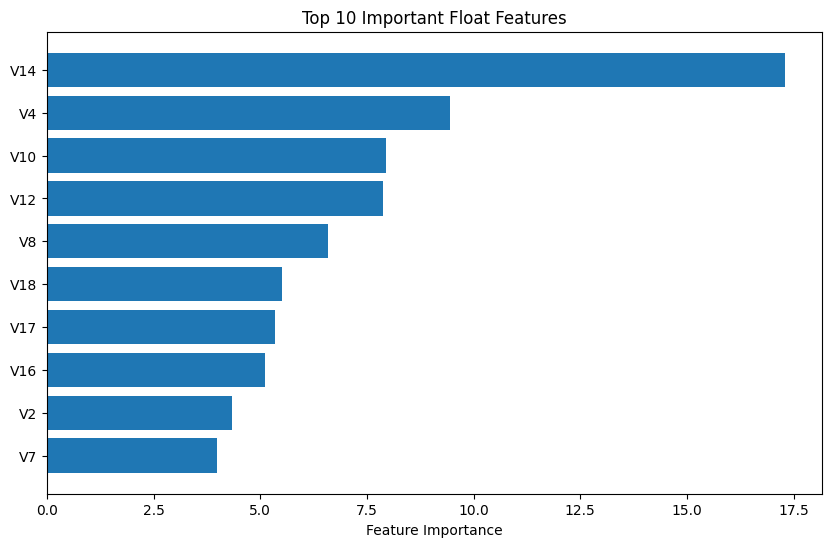

In [ ]:
feature_importance = catboost.feature_importances_
sorted_idx = np.argsort(feature_importance)[-10:] # Top 10

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [X_feature.columns[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Top 10 Important Float Features')
plt.show()

In [25]:
# GradientBoostingClassifier/decisiontree
# gb_clf = GradientBoostingClassifier(
#     n_estimators=100,      # 트리 개수
#     learning_rate=0.1,     # 학습률
#     max_depth=3,           # 개별 트리 깊이
#     random_state=42
# )

# 학습
# gb_clf.fit(X_train, y_train)
user_utils.get_model_train_eval(gb_clf,'capped_data_gb_20251126',X_train,X_test,y_train,y_test)

# 예측
# y_pred = gb_clf.predict(X_test)
# y_pred_proba = gb_clf.predict_proba(X_test)[:, 1]

# # 평가
# print(f"ROC-AUC:{roc_auc_score(y_test, y_pred_proba):.4f}")
# print(f'recall: {recall_score(y_test, y_pred):.4f}')
# print(f'precision: {precision_score(y_test, y_pred):.4f}')
# print(classification_report(y_test, y_pred))

# ROC-AUC: 0.3673
# recall: 0.2347
# precision: 0.6389

# ROC-AUC:0.9871
# recall: 0.8469
# precision: 0.6587

✓ 모델 저장 완료: ../models\capped_data_gb_20251126.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9871, 정확도: 0.9990, 정밀도: 0.6587, 재현율: 0.8469, F1: 0.7411
오차행렬:
[[56820    43]
 [   15    83]]
실행 시간: 330.9938578605652


In [26]:
# 모델 생성
# dt_clf = DecisionTreeClassifier(
#     criterion="gini",   # 분할 기준 (gini, entropy)
#     max_depth=None,     # 트리 최대 깊이 (None이면 제한 없음)
#     random_state=42
# )

# 학습
# dt_clf.fit(X_train, y_train)
user_utils.get_model_train_eval(dt_clf,'capped_data_dt_20251126',X_train,X_test,y_train,y_test)
# # 예측
# y_pred = dt_clf.predict(X_test)
# y_pred_proba = dt_clf.predict_proba(X_test)[:, 1]

# # 평가
# print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}')
# print(f'recall: {recall_score(y_test, y_pred):.4f}')
# print(f'precision: {precision_score(y_test, y_pred):.4f}')
# print(classification_report(y_test, y_pred))

# ROC-AUC: 0.8619
# recall: 0.7245
# precision: 0.6636

# ROC-AUC: 0.9129
# recall: 0.8265
# precision: 0.6750

✓ 모델 저장 완료: ../models\capped_data_dt_20251126.pkl
  파일 크기: 0.03 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9129, 정확도: 0.9990, 정밀도: 0.6750, 재현율: 0.8265, F1: 0.7431
오차행렬:
[[56824    39]
 [   17    81]]
실행 시간: 14.154706239700317


In [27]:

# mlp_clf = MLPClassifier(
#     hidden_layer_sizes=(64, 32),
#     activation="relu",
#     solver="adam",
#     alpha=1e-4,
#     batch_size=256,
#     learning_rate="adaptive",
#     max_iter=50,           # increase with early stopping if desired
#     random_state=23
# )
# 학습
mlp_clf.fit(X_train, y_train)
user_utils.get_model_train_eval(mlp_clf,'capped_data_mlp_20251126',X_train,X_test,y_train,y_test)
# 예측
y_pred = mlp_clf.predict(X_test)
y_pred_proba = mlp_clf.predict_proba(X_test)[:, 1]

# 평가
print("MLP ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print(f'recall: {recall_score(y_test, y_pred):.4f}')
print(f'precision: {precision_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred))

#MLP ROC-AUC: 0.9588918924350831
# recall: 0.7959
# precision: 0.8764

# MLP ROC-AUC: 0.9736846922086634
# recall: 0.8367
# precision: 0.8367

✓ 모델 저장 완료: ../models\capped_data_mlp_20251126.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9737, 정확도: 0.9994, 정밀도: 0.8367, 재현율: 0.8367, F1: 0.8367
오차행렬:
[[56847    16]
 [   16    82]]
실행 시간: 27.979076623916626
MLP ROC-AUC: 0.9736846922086634
recall: 0.8367
precision: 0.8367
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.84      0.84      0.84        98

    accuracy                           1.00     56961
   macro avg       0.92      0.92      0.92     56961
weighted avg       1.00      1.00      1.00     56961



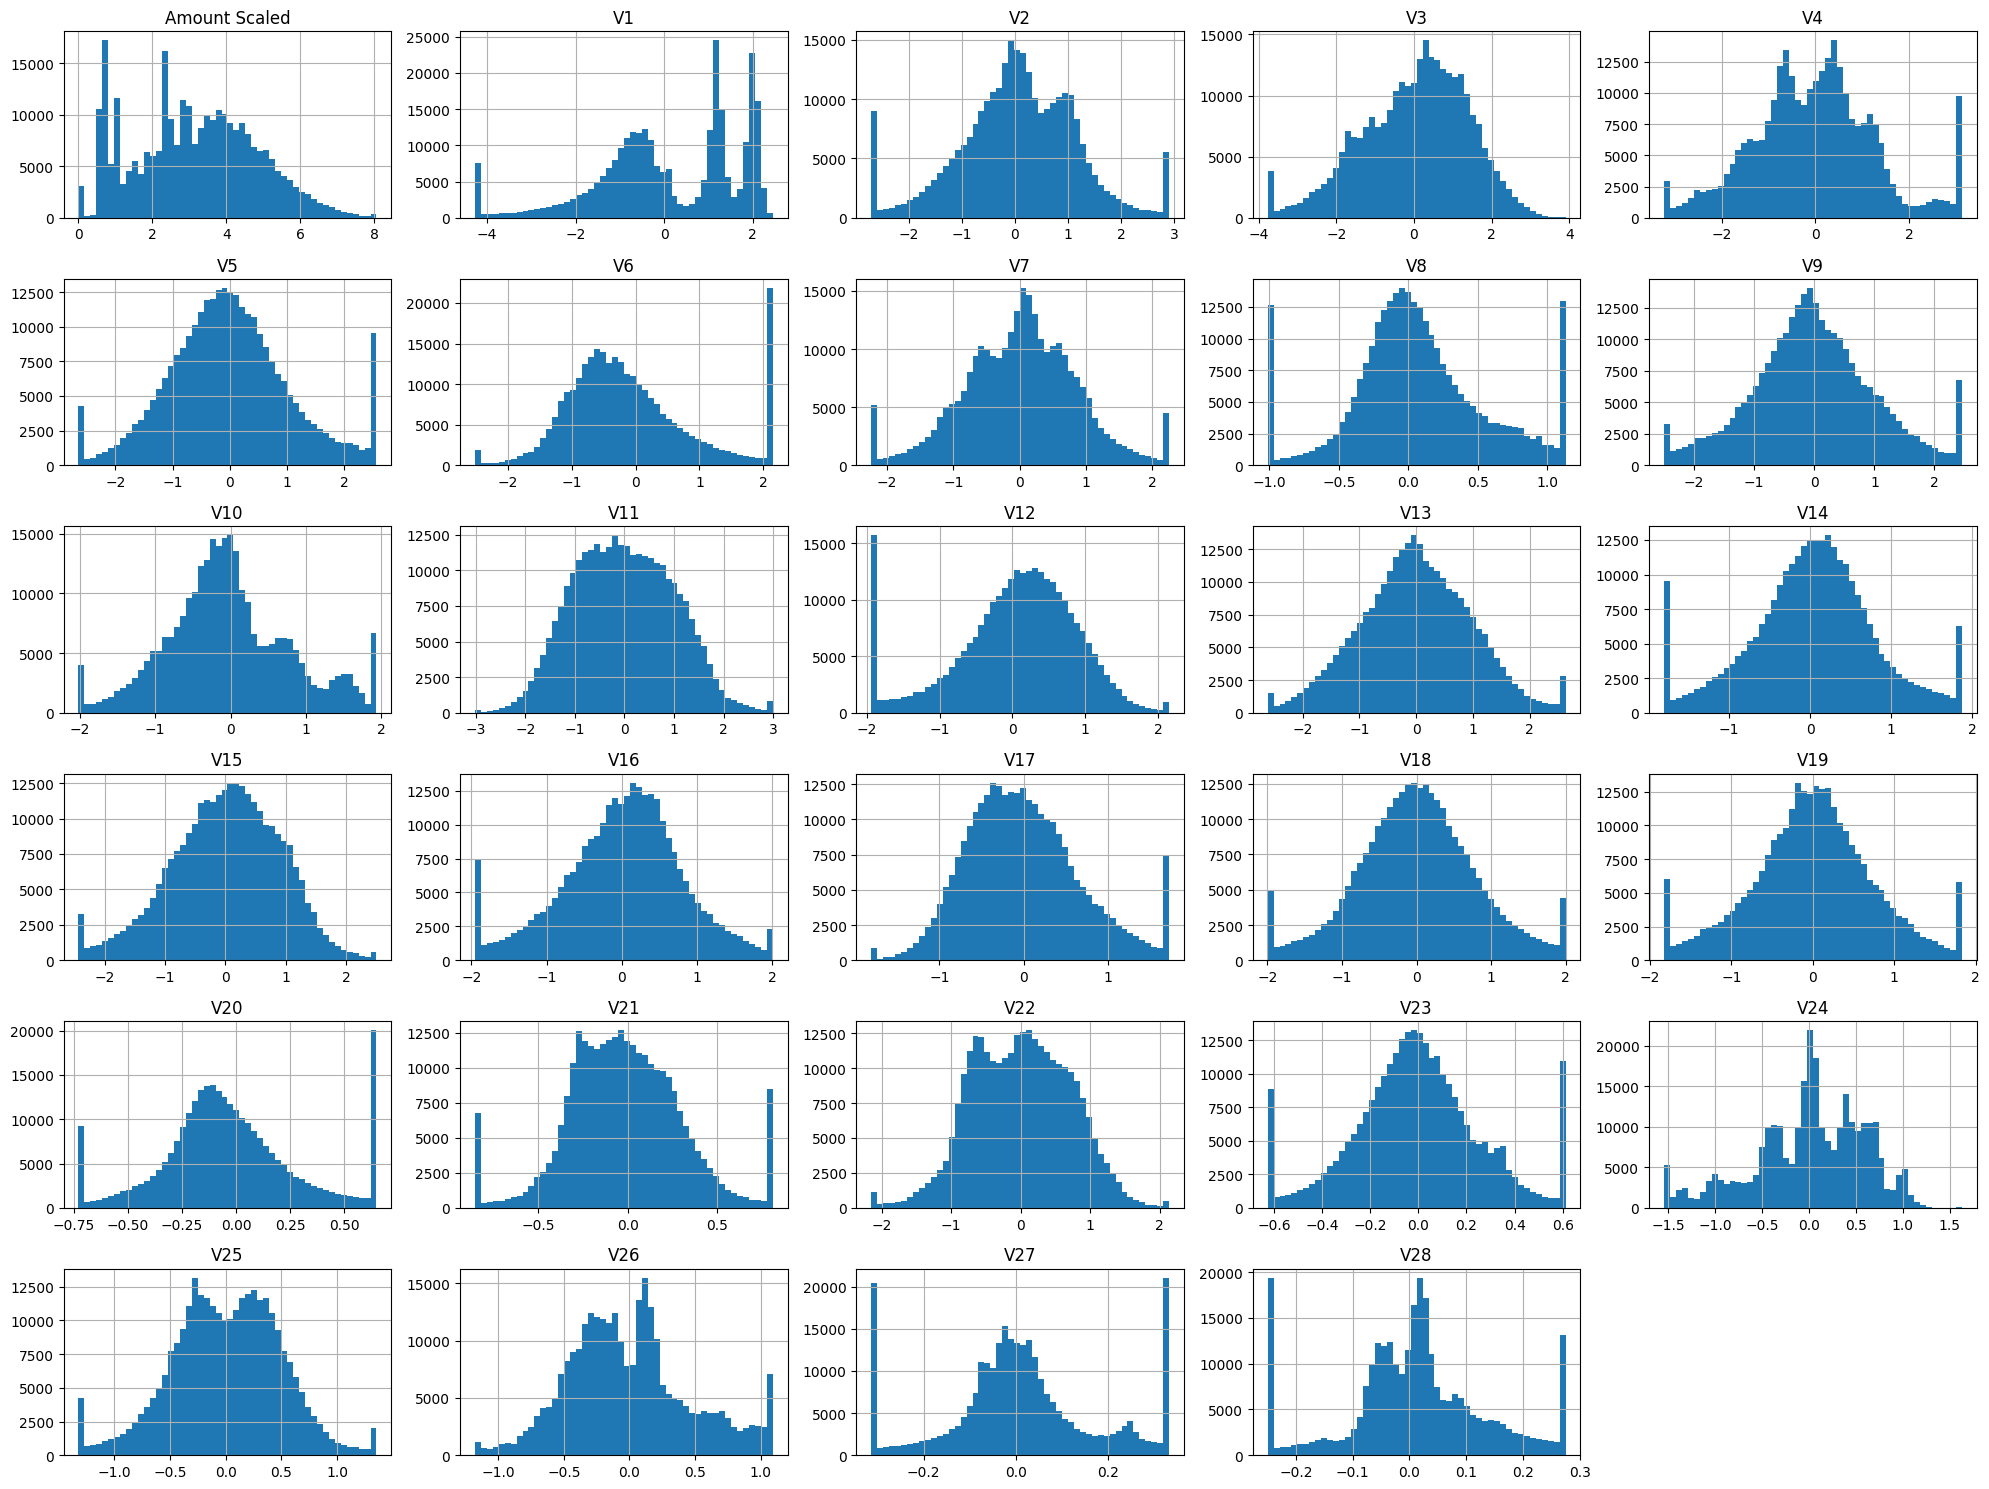

In [56]:
# X_feature의 각 컬럼에 대한 히스토그램을 그려 데이터 분포를 시각화합니다.
plt.figure(figsize=(20, 15))
n_cols = 5
n_rows = (len(X_feature.columns) + n_cols - 1) // n_cols
for i, col in enumerate(X_feature.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    X_feature[col].hist(bins=50)
    plt.title(col)
    plt.tight_layout()

In [31]:
user_utils.get_model_train_eval(lr_clf,'capped_data_lr_20251126',X_train,X_test,y_train,y_test)

✓ 모델 저장 완료: ../models\capped_data_lr_20251126.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
AUC: 0.9892, 정확도: 0.9683, 정밀도: 0.0486, 재현율: 0.9388, F1: 0.0924
오차행렬:
[[55062  1801]
 [    6    92]]
실행 시간: 1.0605077743530273
